# EDA Assignment

---

**EDA Project Instructions**

1. **Read Each Task Carefully**: Understand each task’s requirements before starting your analysis.

2. **Perform the Analysis**: For each task, you’ll find a description in the code cell. Write your code directly in the provided cells to perform the necessary analysis using the Heart Attack dataset.

3. **Visualize and Interpret**: Create visualizations and interpret the results as needed. Ensure your analysis addresses the specific questions and insights required.

4. **Complete All Tasks**: Make sure you address each task. Each task is designed to test different aspects of data analysis and visualization.

5. **Download Your Notebook**: After completing and reviewing your analysis, download your notebook file (.ipynb) by selecting `File > Download > Download .ipynb`.

6. **Submit Your Work**: Upload the downloaded `.ipynb` file to the designated platform for submission.

7. **Verify Your Submission**: Ensure that you have submitted the correct file and that it is not corrupted. If needed, resubmit the file.

Good luck, and happy analyzing!

---

## Dataset Information :
<ul style= "color:#137667;
            font-size:12px;">
    <li> age : age of the patient</li>
    <li> sex : sex of the patient (0 - Male, 1 - Female)</li>
    <li> cp : Chest Pain type</li>
    0: typical angina <br>
    1: atypical angina <br>
    2: non-anginal pain <br>
    3: asymptomatic <br>
    <li> trtbps : resting blood pressure (in mm Hg)</li>
    <li> fbs : (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)</li>
    <li> chol : cholestoral in mg/dl fetched via BMI sensor</li>
    <li> rest_ecg : resting electrocardiographic results</li>
  0:normal <br>
  1:having ST-T wave abnormality(T wave inversions and/or ST elevation or depression of>0.05 mV) <br>
  2:showing probable or definite left ventricular hypertrophy by Estes' criteria
    <li> thalachh : maximum heart rate achieved</li>
    <li> exng : exercise induced angina (1 = yes; 0 = no)</li>
    <li> oldpeak : Previous peak</li>
    <li> slp : ST/HR Slope </li>
    <li> caa : number of major vessels (0-4)</li>
    <li> thall : Thal rate</li>
    <li> output : 0= less chance of heart attack 1= more chance of heart attack</li>
</ul>

In [4]:
# Run this code cell for initial setup
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [5]:
# load the data to colab
data = pd.read_csv('/content/e8697469-fd7e-4605-87fe-db9141da3f5c_heart.csv')
data.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
5,57,1,0,140,192.0,0,1,148.0,0.0,0.4,1,0,1,1
6,56,0,1,140,294.0,0,0,153.0,0.0,1.3,1,0,2,1
7,44,1,1,120,263.0,0,1,173.0,0.0,0.0,2,0,3,1
8,52,1,2,172,199.0,1,1,162.0,0.0,0.5,2,0,3,1
9,57,1,2,150,168.0,0,1,174.0,0.0,1.6,2,0,2,1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       324 non-null    int64  
 1   sex       324 non-null    int64  
 2   cp        324 non-null    int64  
 3   trtbps    324 non-null    int64  
 4   chol      321 non-null    float64
 5   fbs       324 non-null    int64  
 6   restecg   324 non-null    int64  
 7   thalachh  320 non-null    float64
 8   exng      321 non-null    float64
 9   oldpeak   324 non-null    float64
 10  slp       324 non-null    int64  
 11  caa       324 non-null    int64  
 12  thall     324 non-null    int64  
 13  output    324 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 35.6 KB


---
---
**1. Check the presence of duplicate values and deal with them.**

In [7]:
data.duplicated().sum()

np.int64(22)

In [ ]:
data.drop_duplicates(inplace = True)
data

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241.0,0,1,123.0,1.0,0.2,1,0,3,0
299,45,1,3,110,264.0,0,1,132.0,0.0,1.2,1,0,3,0
300,68,1,0,144,193.0,1,1,141.0,0.0,3.4,1,2,3,0
301,57,1,0,130,131.0,0,1,115.0,1.0,1.2,1,1,3,0


---
---
**2.Check the presence of missing values and deal with them.**

In [8]:
# write your code here
data.isnull().sum()

# chol column (continuous numerical)
data['chol'].fillna(data['chol'].median(), inplace = True)
# thalachh (continuous numerical)
data['thalachh'].fillna( data['thalachh'].median(), inplace = True)

# exng (categorical)
mode_emb =  data.exng.dropna().mode()[0]
data['exng'].fillna(mode_emb, inplace = True)


---
---
**3.Determine mean, standard deviation and quartiles(q1,q2,q3) for following columns:**
   - age
   - trtbps
   - chol
   - thalachh

In [9]:
# write your code here
print(' Mean of age' , data['age'].mean())
print(' Mean of trtbps' , data['trtbps'].mean())
print(' Mean of chol' , data['chol'].mean())
print(' Mean of thalachh' , data['thalachh'].mean())
#Standard deviation
print('Standard Deviation of age', data['age'].std())
print('Standard Deviation of trtbps', data['trtbps'].std())
print('Standard Deviation of chol', data['chol'].std())
print('Standard Deviation of thalachh', data['thalachh'].std())
#Quartiles
q1 = data['age'].quantile(0.25)
q2 = data['trtbps'].quantile(0.50)
q3 = data['chol'].quantile(0.75)
print(q1,q2,q3)
IQR = q3 - q1
print(IQR)


 Mean of age 54.51851851851852
 Mean of trtbps 131.9506172839506
 Mean of chol 244.5462962962963
 Mean of thalachh 149.1172839506173
Standard Deviation of age 8.98621043511536
Standard Deviation of trtbps 17.49880224795791
Standard Deviation of chol 50.83045044186076
Standard Deviation of thalachh 22.68109394014316
48.0 130.0 273.25
225.25


---
---
**4.Analyse whether males or females are at a higher risk of heart attack.**

In [10]:
mpl.style.use('dark_background')

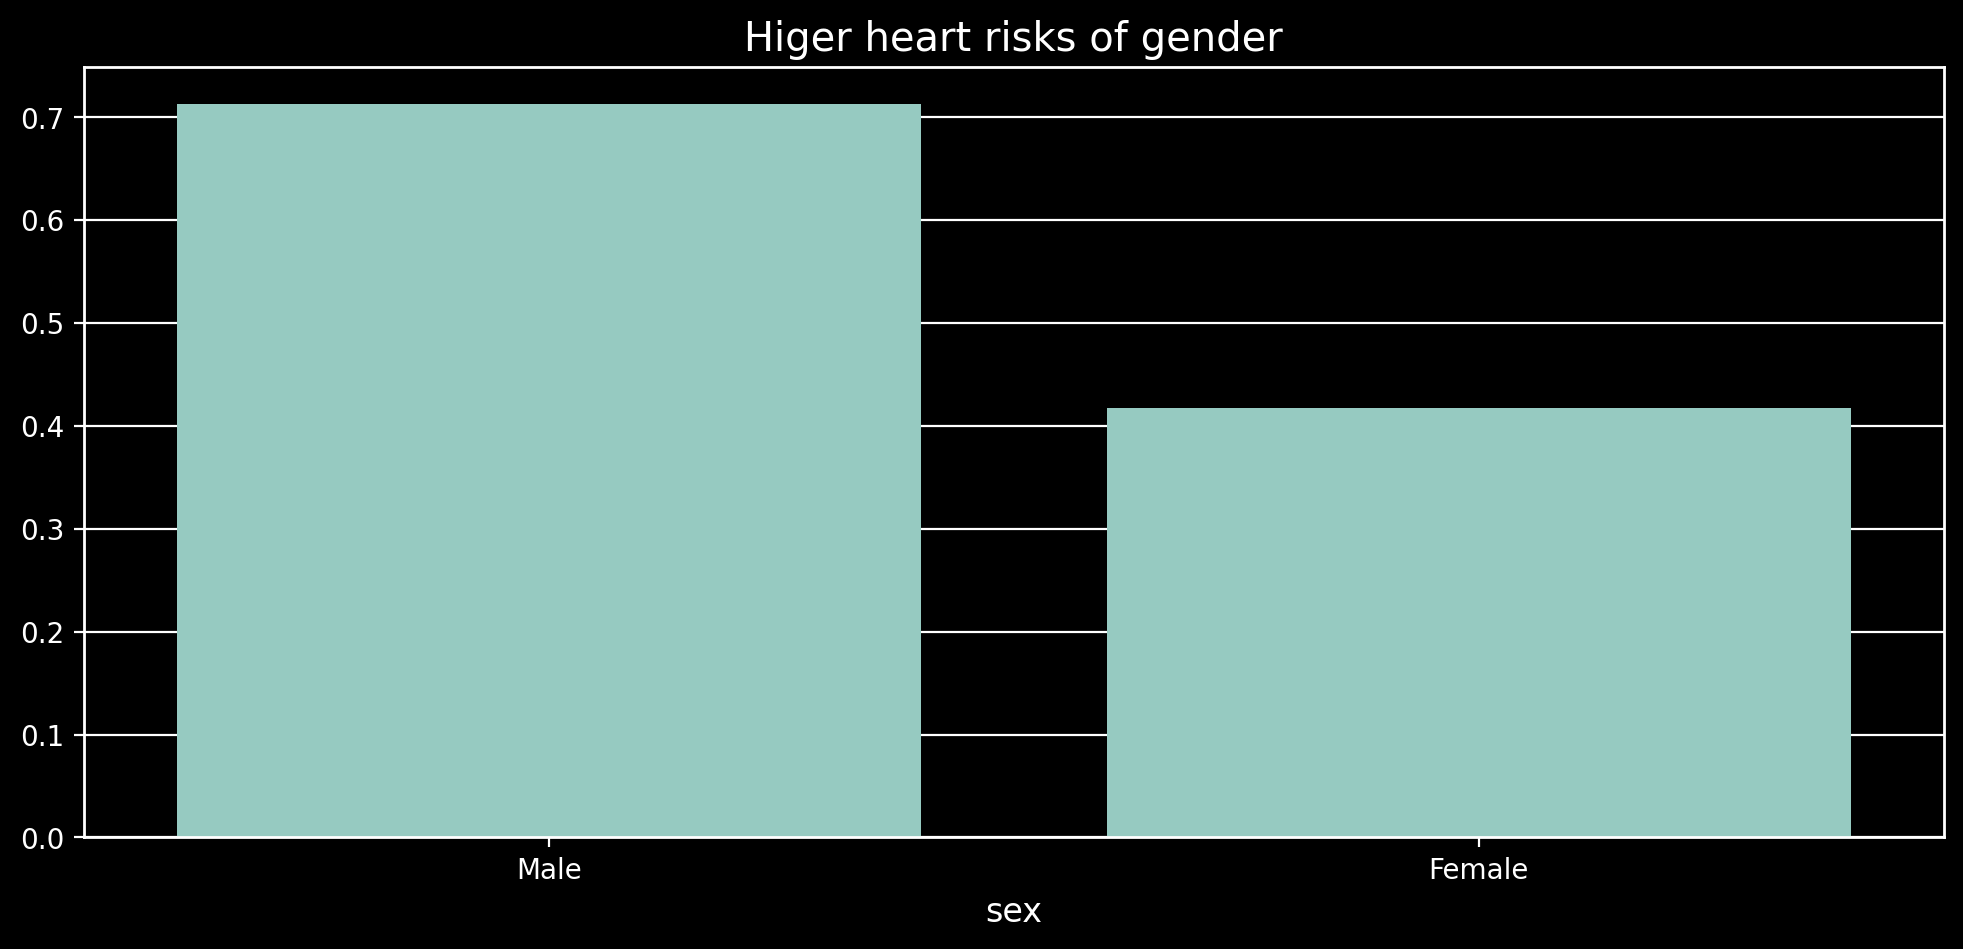

In [11]:
main = data.groupby('sex')['output'].mean()

main = main.rename({0:'Male', 1:"Female"})
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x = main.index, y = main.values)
plt.title('Higer heart risks of gender')
plt.show()


   restecg    output
0        0  0.441558
1        1  0.585366
2        2  0.166667


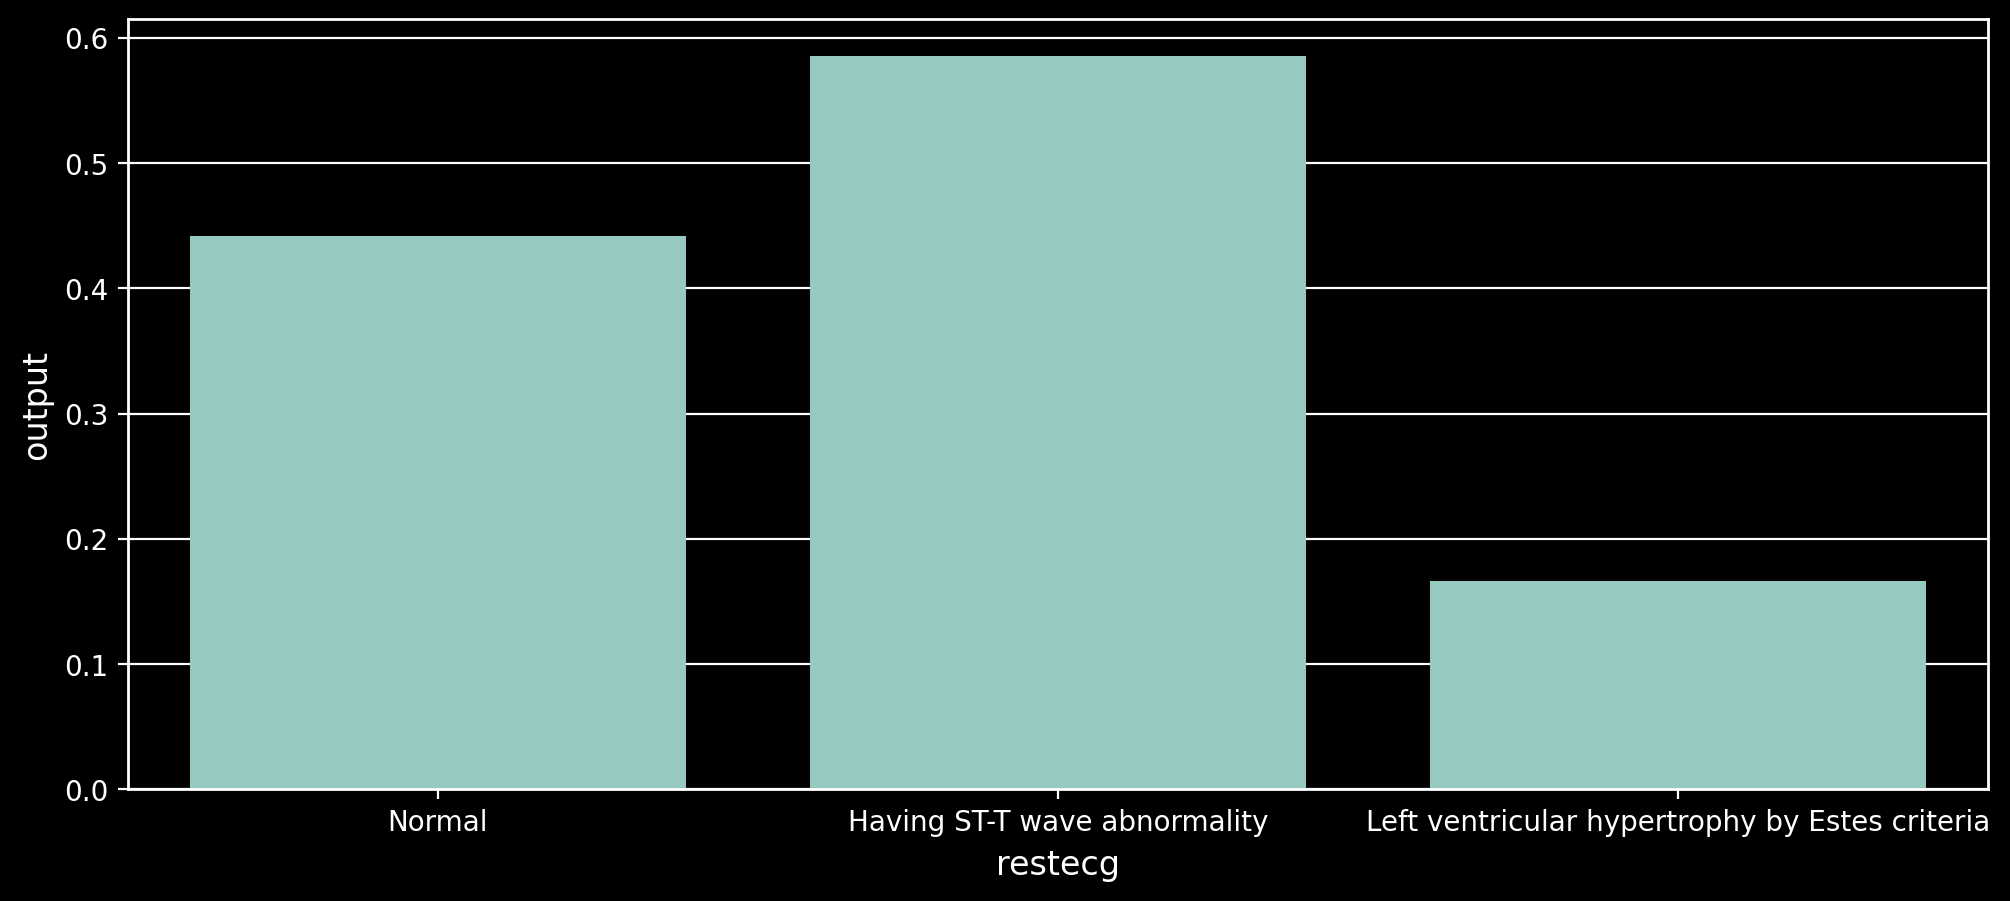

In [12]:
new_one = data.groupby('restecg')['output'].mean().reset_index()
print(new_one)
new_one['restecg']= new_one['restecg'].replace({0:'Normal', 1:'Having ST-T wave abnormality',2:'Left ventricular hypertrophy by Estes criteria'})
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x = 'restecg', y = 'output', data = new_one)


plt.show()

fbs
Less chance of heart attack    0.516364
More chance of heart attack    0.469388
Name: output, dtype: float64


<Axes: xlabel='fbs'>

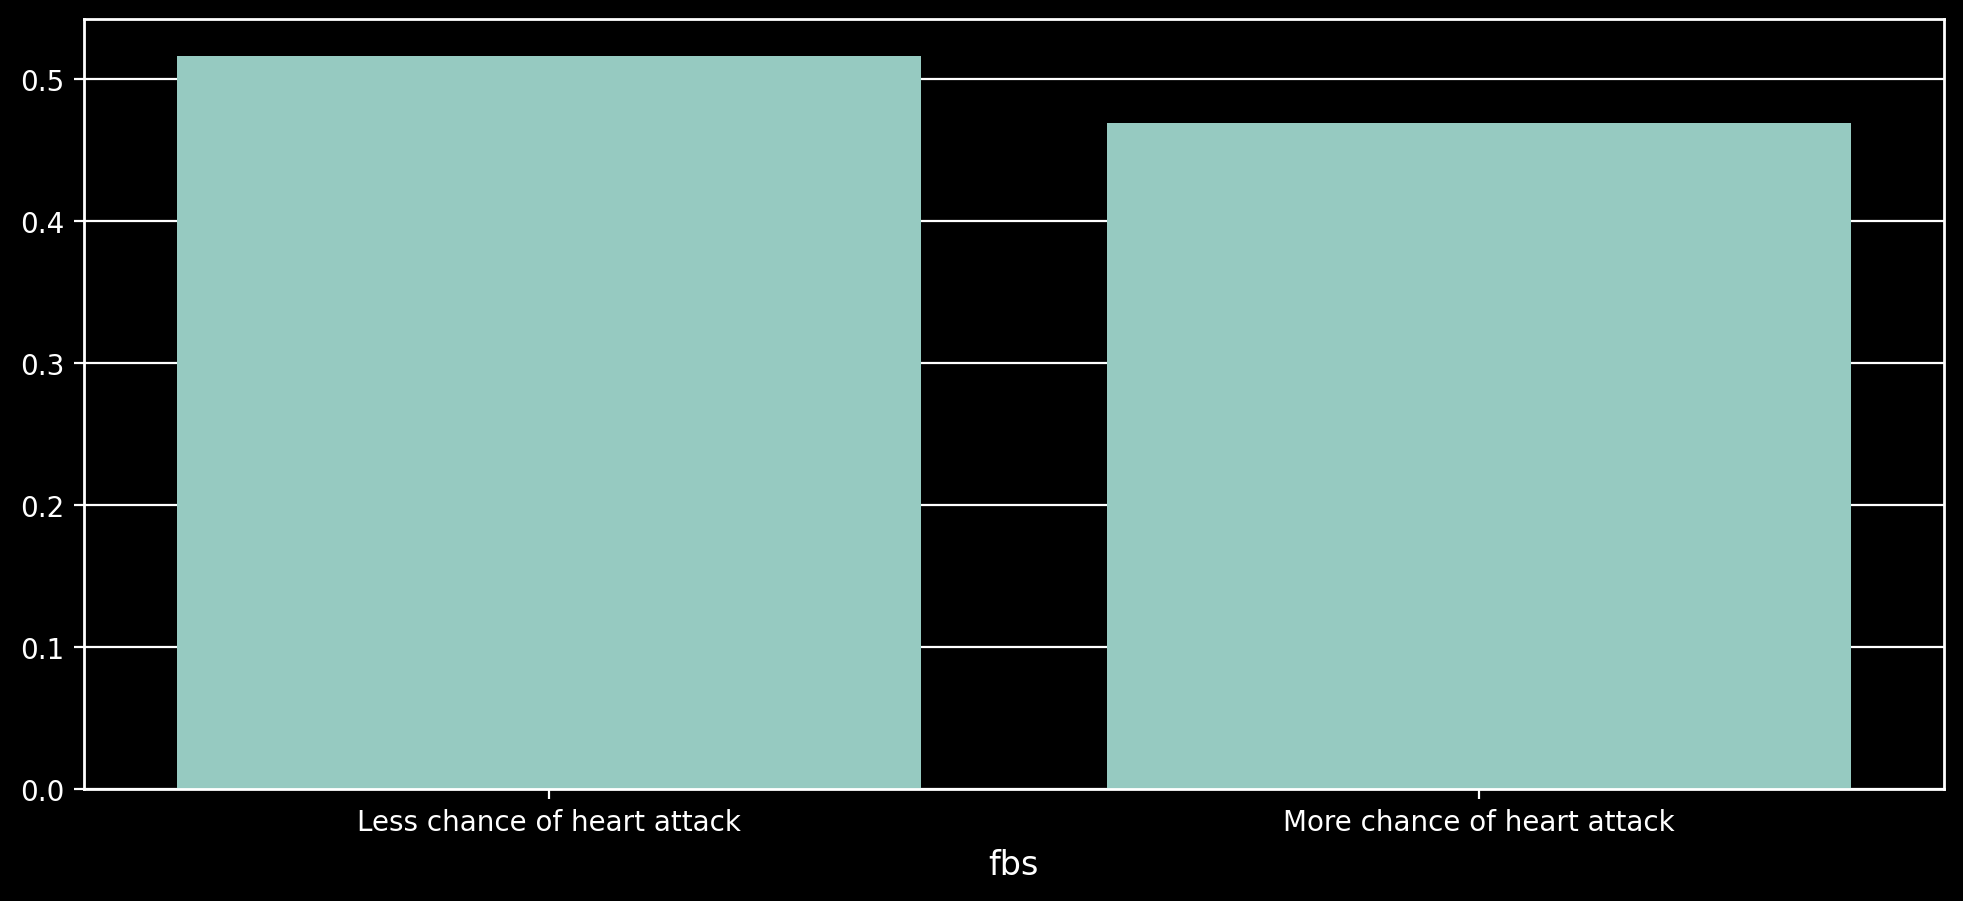

In [13]:
new_two = data.groupby('fbs')['output'].mean()
new_two = new_two.rename({0:'Less chance of heart attack', 1:'More chance of heart attack'})
print(new_two)
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x = new_two.index, y = new_two.values)


In [ ]:
data

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,57,0,0,140,241.0,0,1,123.0,1.0,0.2,1,0,3,0
320,45,1,3,110,264.0,0,1,132.0,0.0,1.2,1,0,3,0
321,68,1,0,144,193.0,1,1,141.0,0.0,3.4,1,2,3,0
322,57,1,0,130,131.0,0,1,115.0,1.0,1.2,1,1,3,0


**5.Patients with which type of chest pain are at highest risk of heart attack.**

<Axes: xlabel='cp', ylabel='output'>

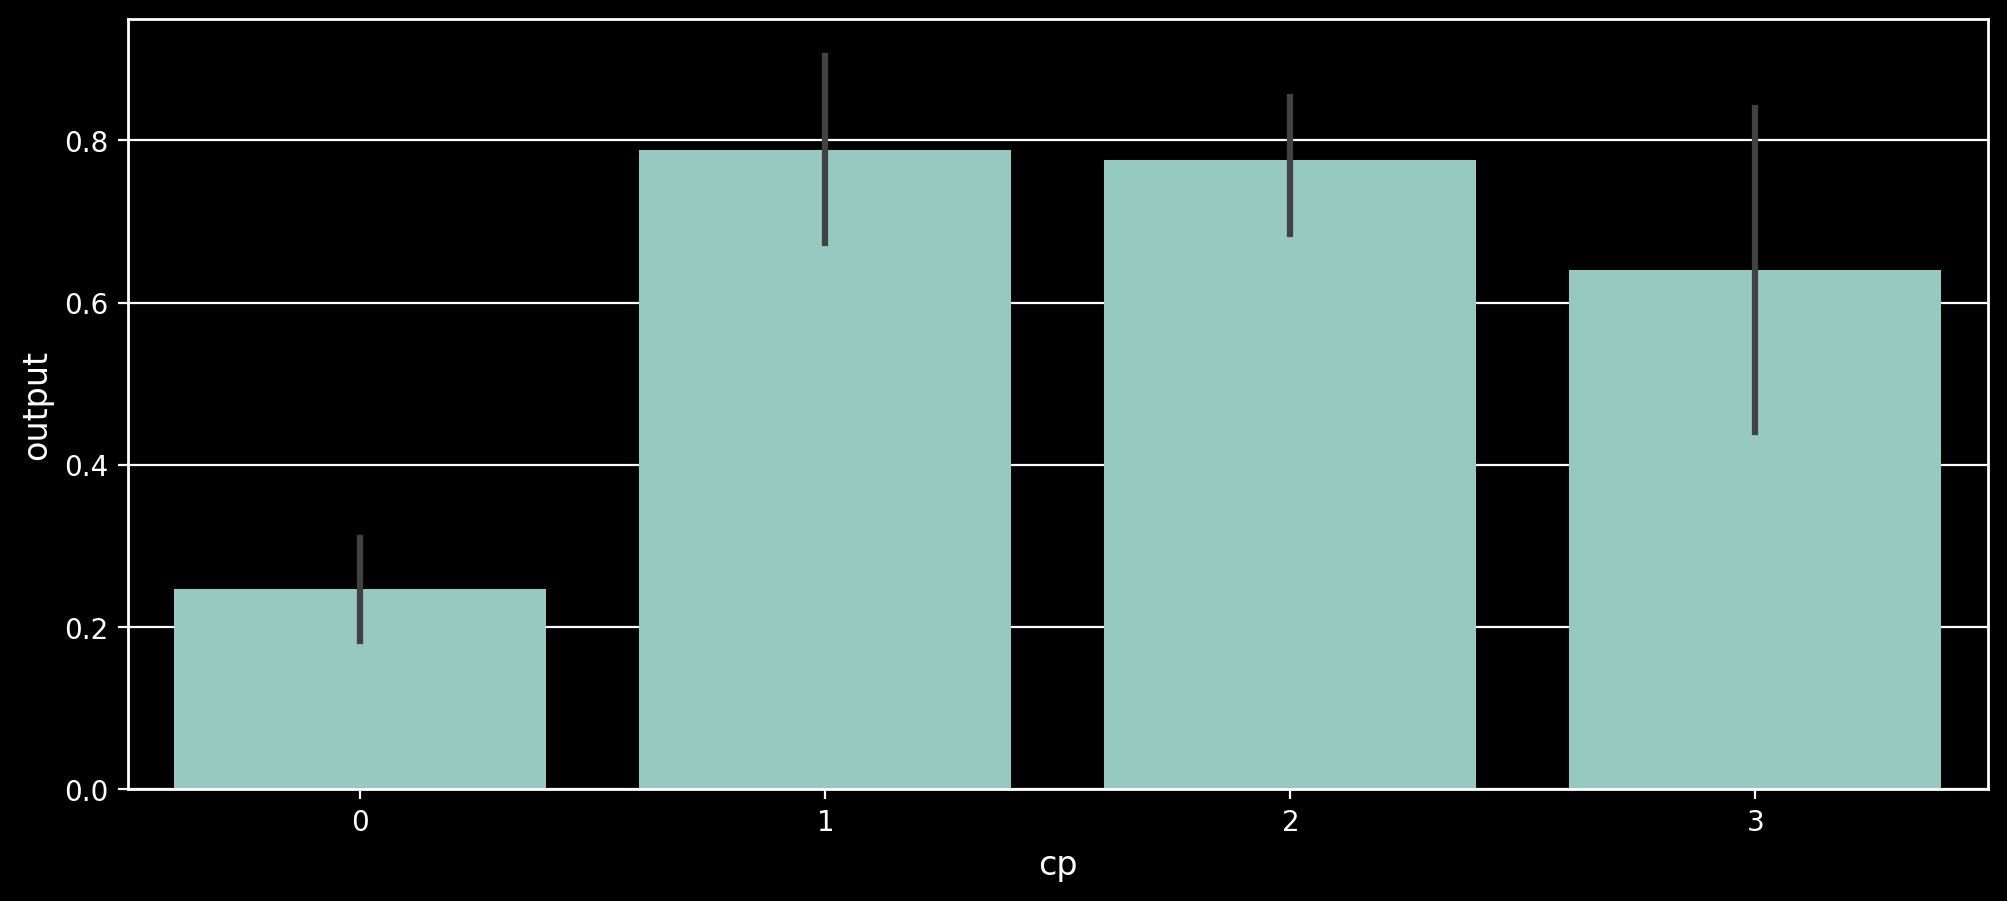

In [14]:
data.groupby('cp')['output'].mean().reset_index()
data = data.rename({0:''})
plt.figure(figsize = (12,5), dpi = 200)
sns.barplot(x = 'cp', y  = 'output', data = data)



---
---
**6.Analyse the effect of age on heart attack risk.**

age
29    1.000000
34    1.000000
35    0.500000
37    1.000000
38    0.666667
39    0.750000
40    0.250000
41    0.900000
42    0.875000
43    0.625000
44    0.666667
45    0.666667
46    0.500000
47    0.600000
48    0.571429
49    0.600000
50    0.571429
51    0.750000
52    0.692308
53    0.750000
54    0.625000
55    0.333333
56    0.454545
57    0.318182
58    0.333333
59    0.294118
60    0.272727
61    0.100000
62    0.363636
63    0.272727
64    0.600000
65    0.500000
66    0.571429
67    0.300000
68    0.400000
69    0.666667
70    0.250000
71    1.000000
74    1.000000
76    1.000000
77    0.000000
Name: output, dtype: float64


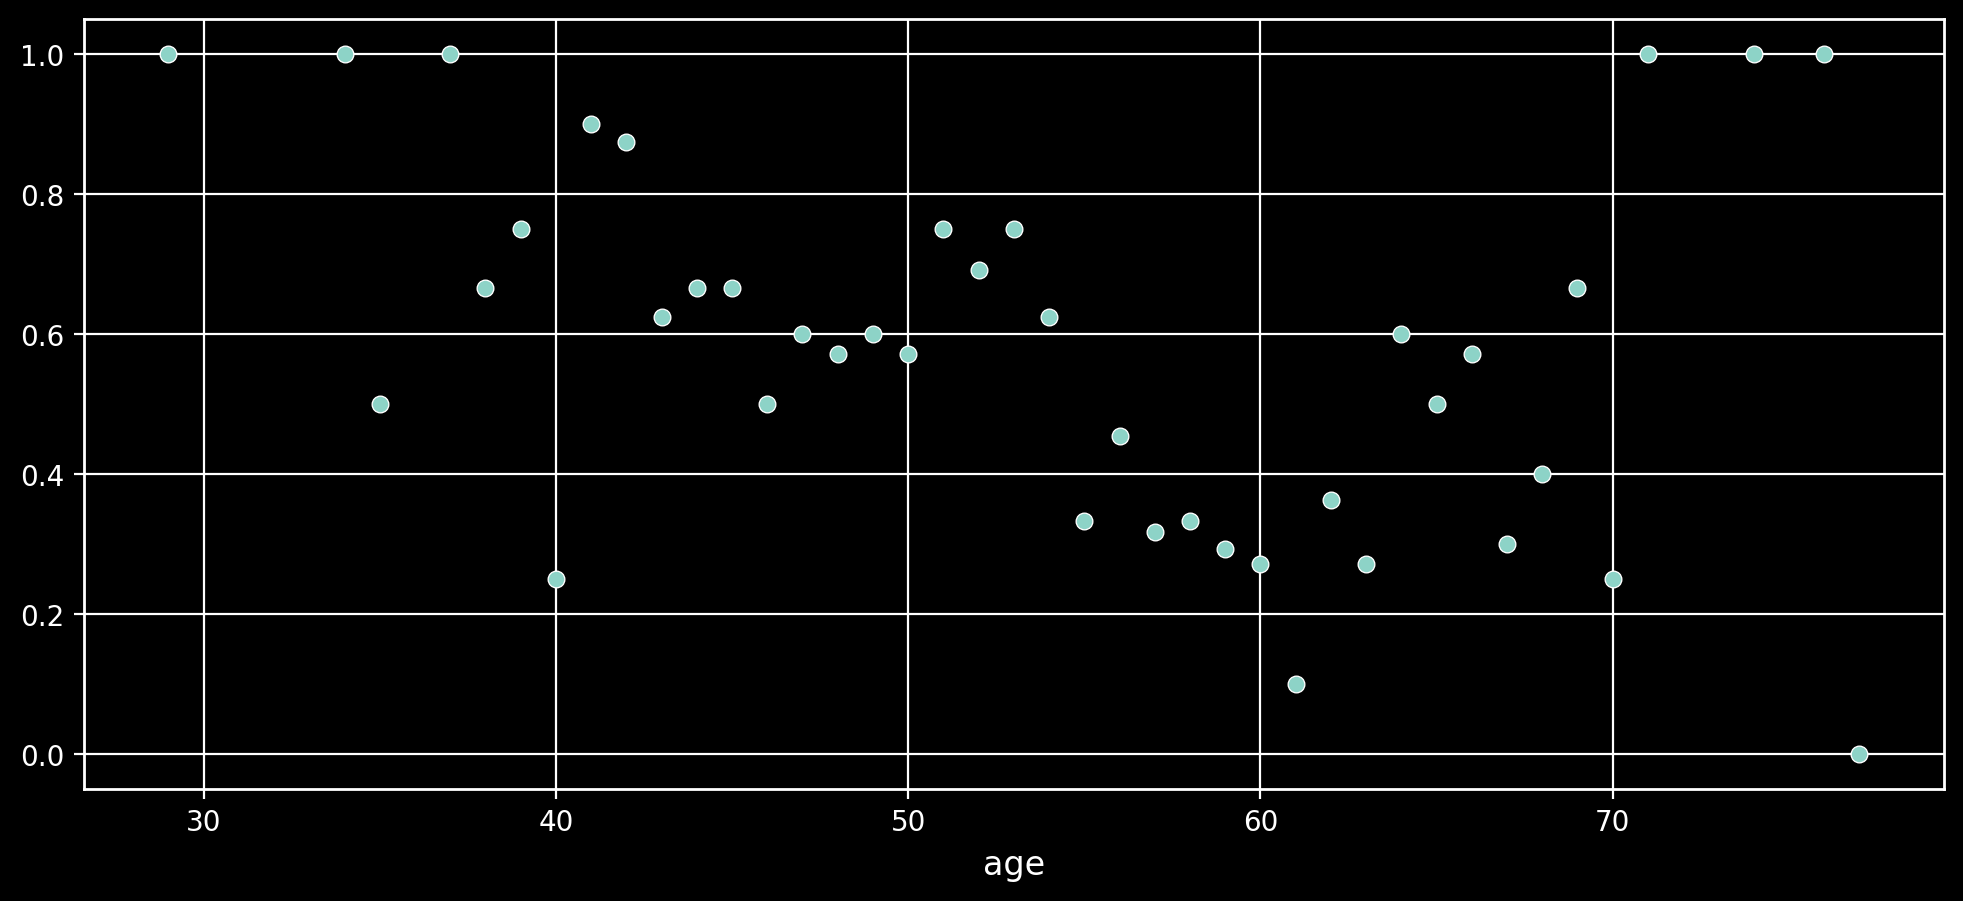

In [34]:
new_ageing = data.groupby('age')['output'].mean()
plt.figure(figsize = (12,5), dpi = 200)
sns.scatterplot(x = new_ageing.index , y = new_ageing.values)
print(new_ageing)




<Axes: xlabel='age'>

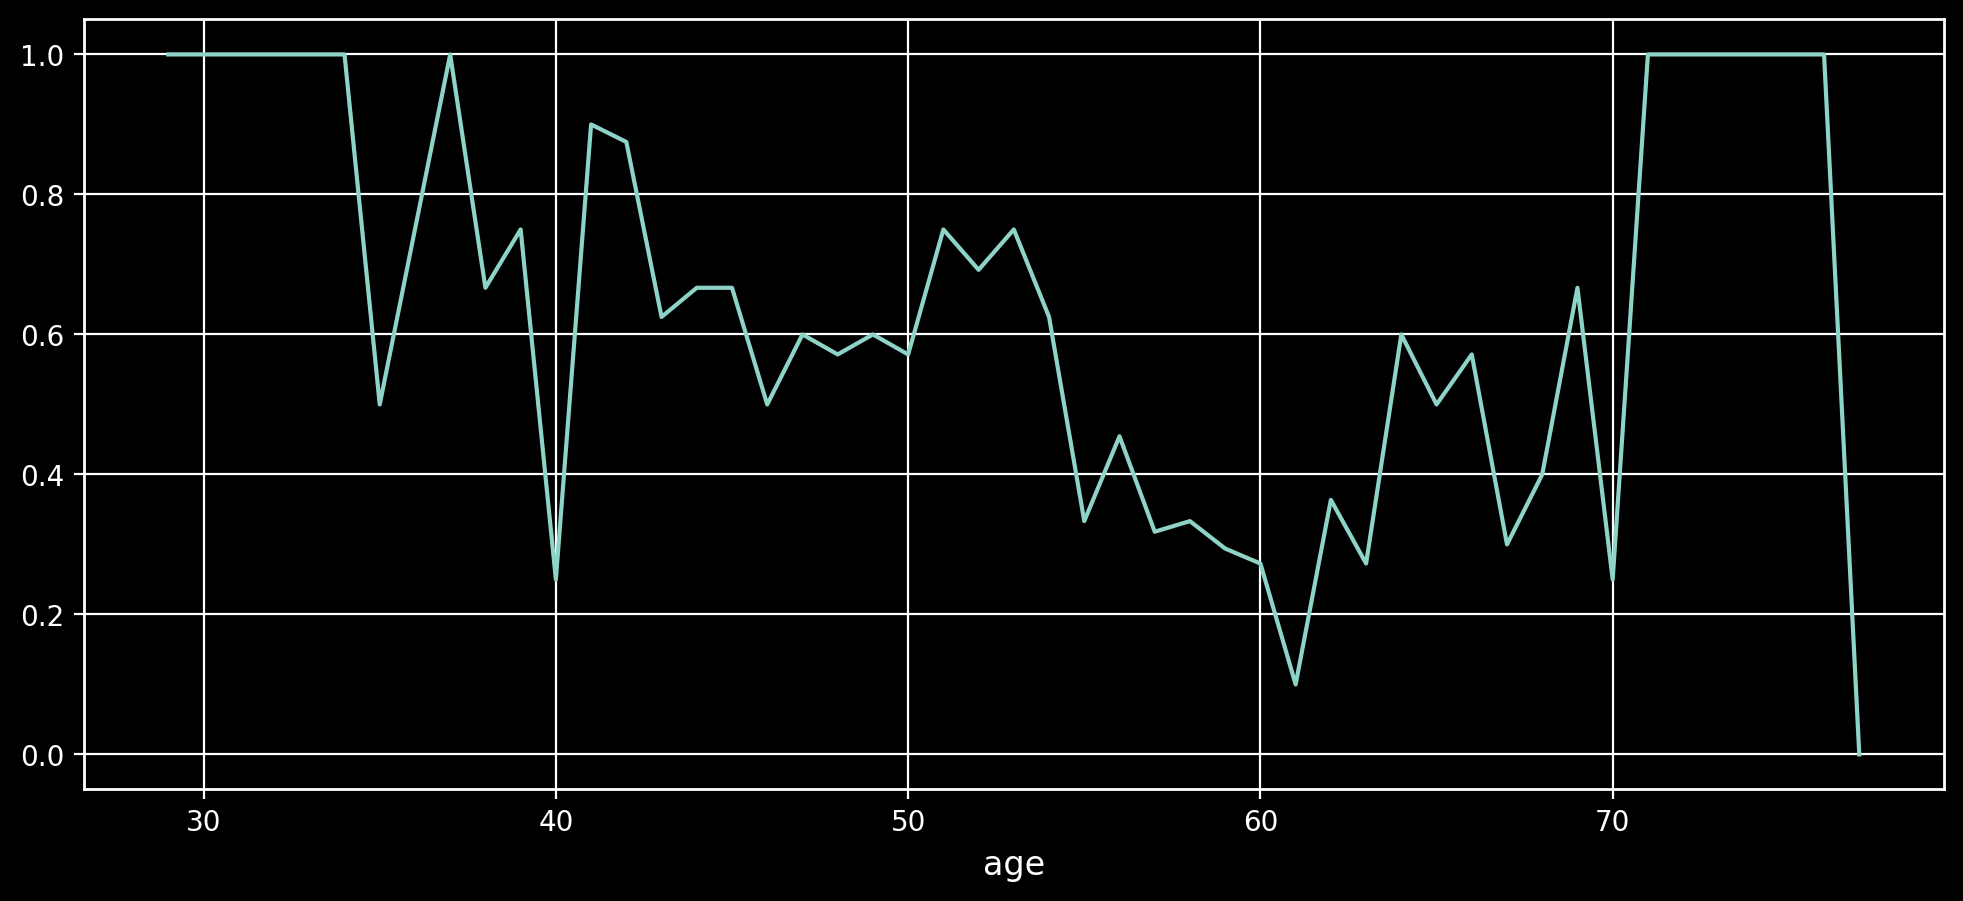

In [35]:
new_ageing = data.groupby('age')['output'].mean()
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(x = new_ageing.index , y = new_ageing.values)


---
---
**7.A higher risk of heart attack is associated more with low fasting blood sugar levels or high fasting blood sugar levels.**

fbs
Less chance of heart attack    0.516364
More chance of heart attack    0.469388
Name: output, dtype: float64


<Axes: xlabel='fbs'>

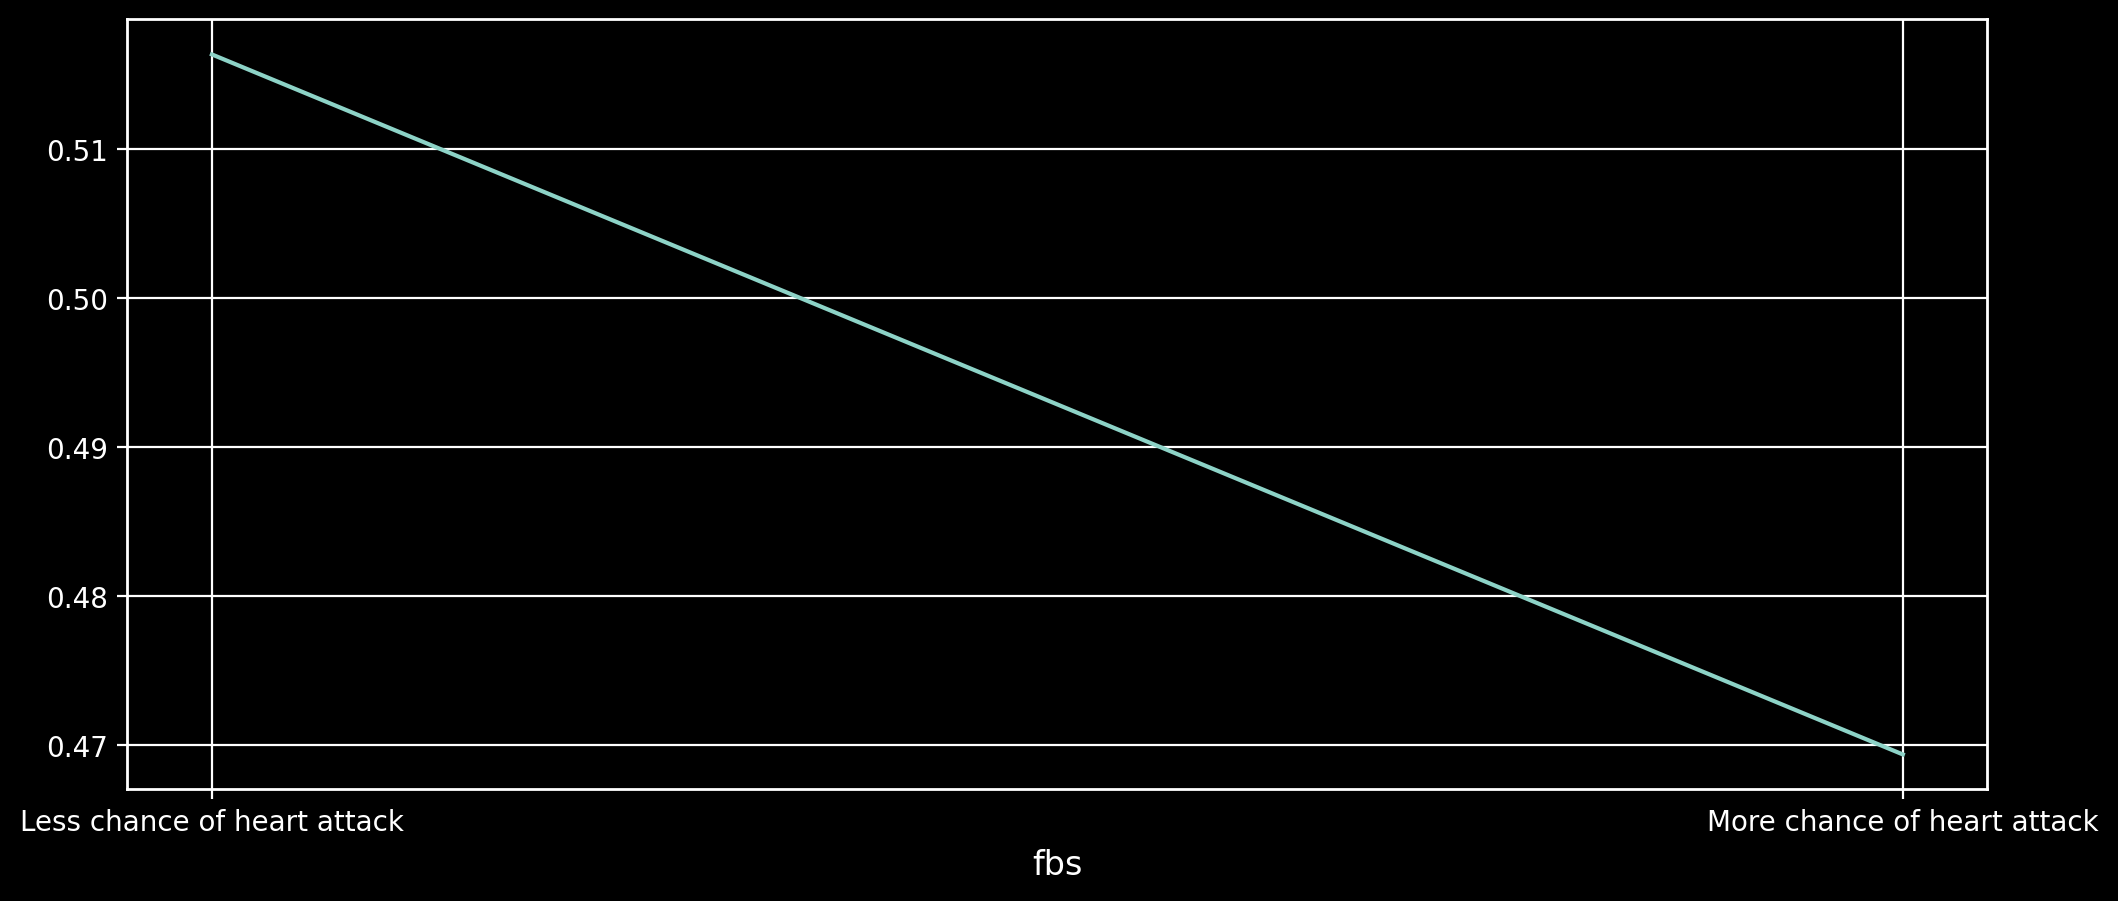

In [40]:
new_two = data.groupby('fbs')['output'].mean()
new_two = new_two.rename({0:'Less chance of heart attack', 1:'More chance of heart attack'})
print(new_two)
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(x = new_two.index, y = new_two.values)

# ---
---
**8.How the risk of heart atack can be determined from resting electrocardiographic results?**

   restecg    output
0        0  0.441558
1        1  0.585366
2        2  0.166667


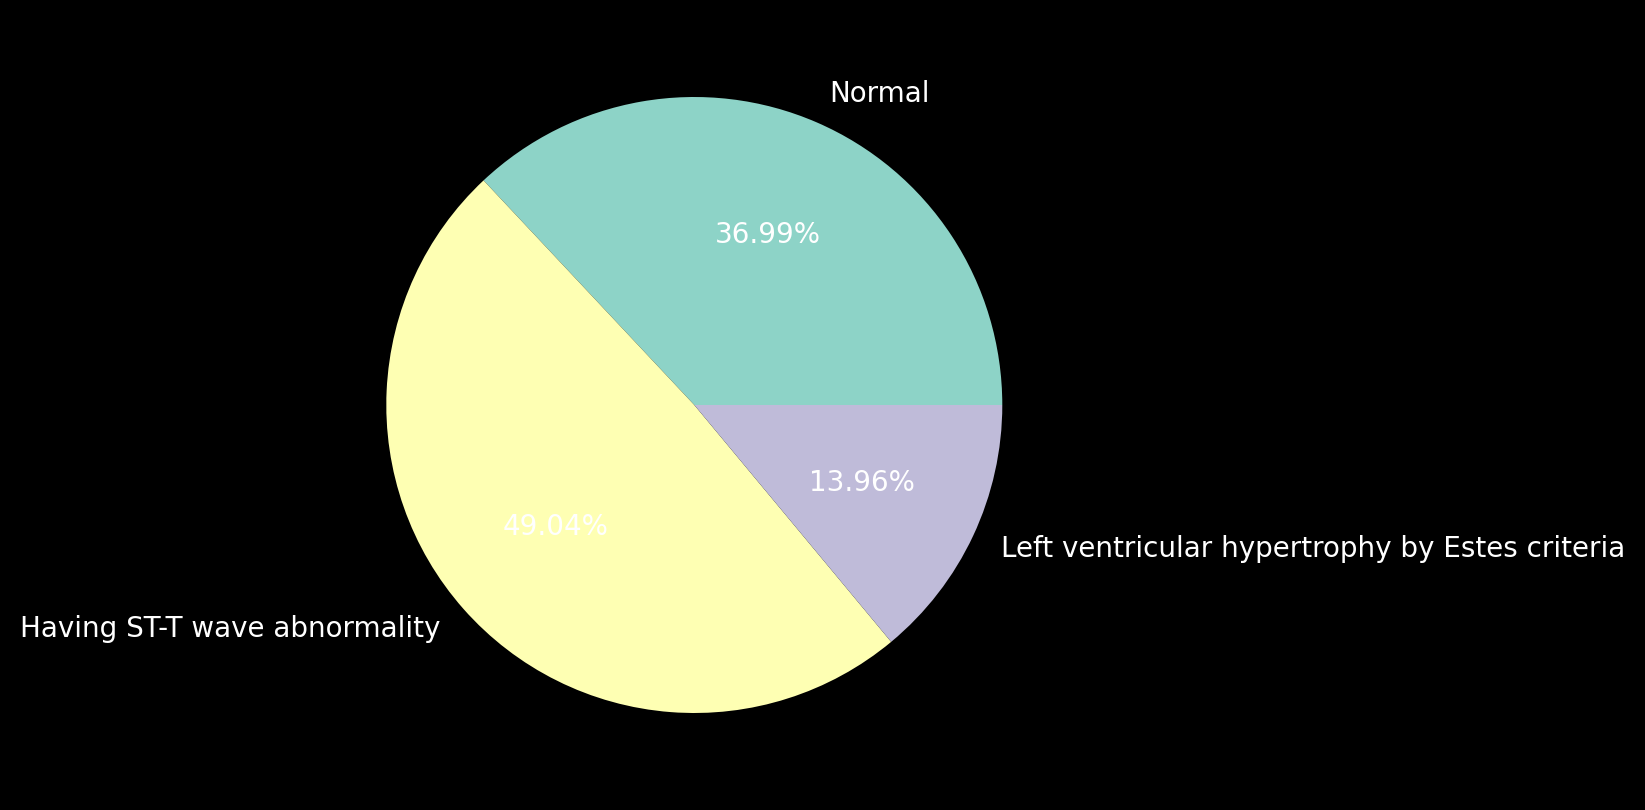

In [68]:
new_one = data.groupby('restecg')['output'].mean().reset_index()
print(new_one)


stages = ['Normal','Having ST-T wave abnormality','Left ventricular hypertrophy by Estes criteria' ]
plt.figure(figsize = (12,5), dpi = 200)
plt.pie( new_one['output']  , labels = stages,  autopct = '%1.2f%%')





plt.show()

---
---
**9. Is resting blood presure a significant factor for detrmining risk of a heart attack?**

(array([ 2.,  8., 10., 35., 46., 23., 56., 23., 49., 13., 27.,  4., 11.,
         3.,  6.,  3.,  3.,  0.,  1.,  1.]),
 array([ 94. ,  99.3, 104.6, 109.9, 115.2, 120.5, 125.8, 131.1, 136.4,
        141.7, 147. , 152.3, 157.6, 162.9, 168.2, 173.5, 178.8, 184.1,
        189.4, 194.7, 200. ]),
 <BarContainer object of 20 artists>)

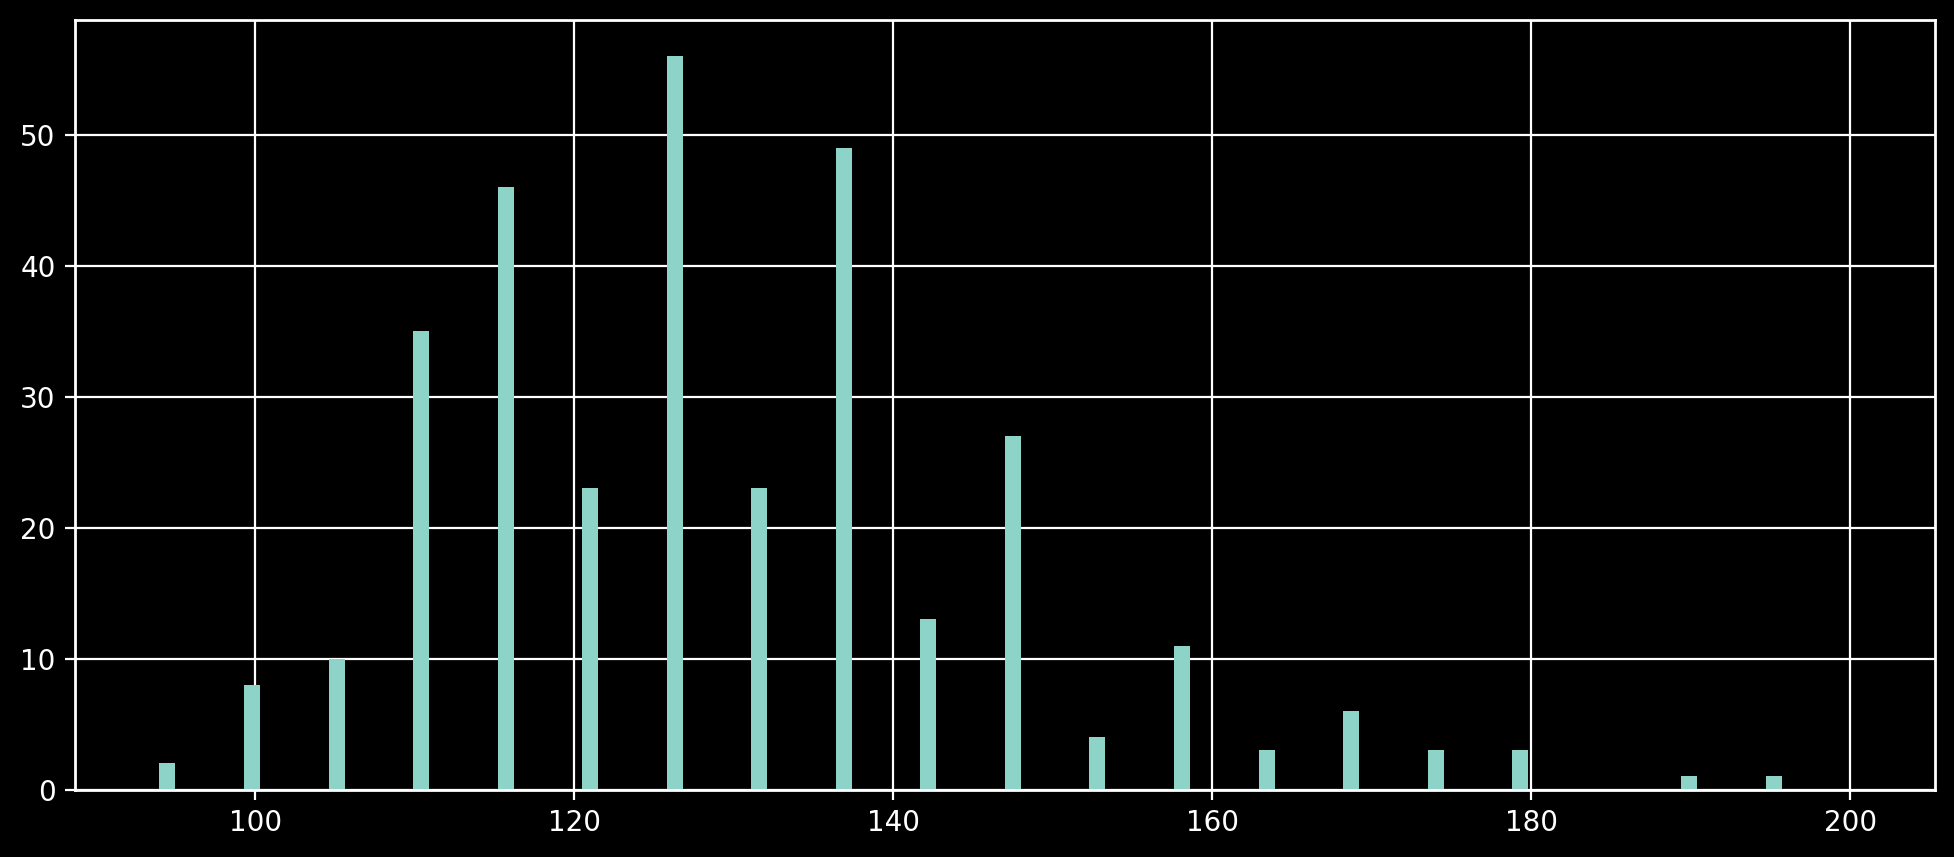

In [73]:
plt.figure(figsize = (12,5), dpi = 200)
plt.hist(data['trtbps'], bins = 20, width = 1)


In [74]:
data

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
,63,1,3,145,233.0,1,0,150.0,0.0,2.3,0,0,1,1
1,37,1,2,130,250.0,0,1,187.0,0.0,3.5,0,0,2,1
2,41,0,1,130,204.0,0,0,172.0,0.0,1.4,2,0,2,1
3,56,1,1,120,236.0,0,1,178.0,0.0,0.8,2,0,2,1
4,57,0,0,120,354.0,0,1,163.0,1.0,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,57,0,0,140,241.0,0,1,123.0,1.0,0.2,1,0,3,0
320,45,1,3,110,264.0,0,1,132.0,0.0,1.2,1,0,3,0
321,68,1,0,144,193.0,1,1,141.0,0.0,3.4,1,2,3,0
322,57,1,0,130,131.0,0,1,115.0,1.0,1.2,1,1,3,0


---
---
**10.Is heart attack risk asociated with a higher heart rate?**

<Axes: xlabel='thalachh', ylabel='output'>

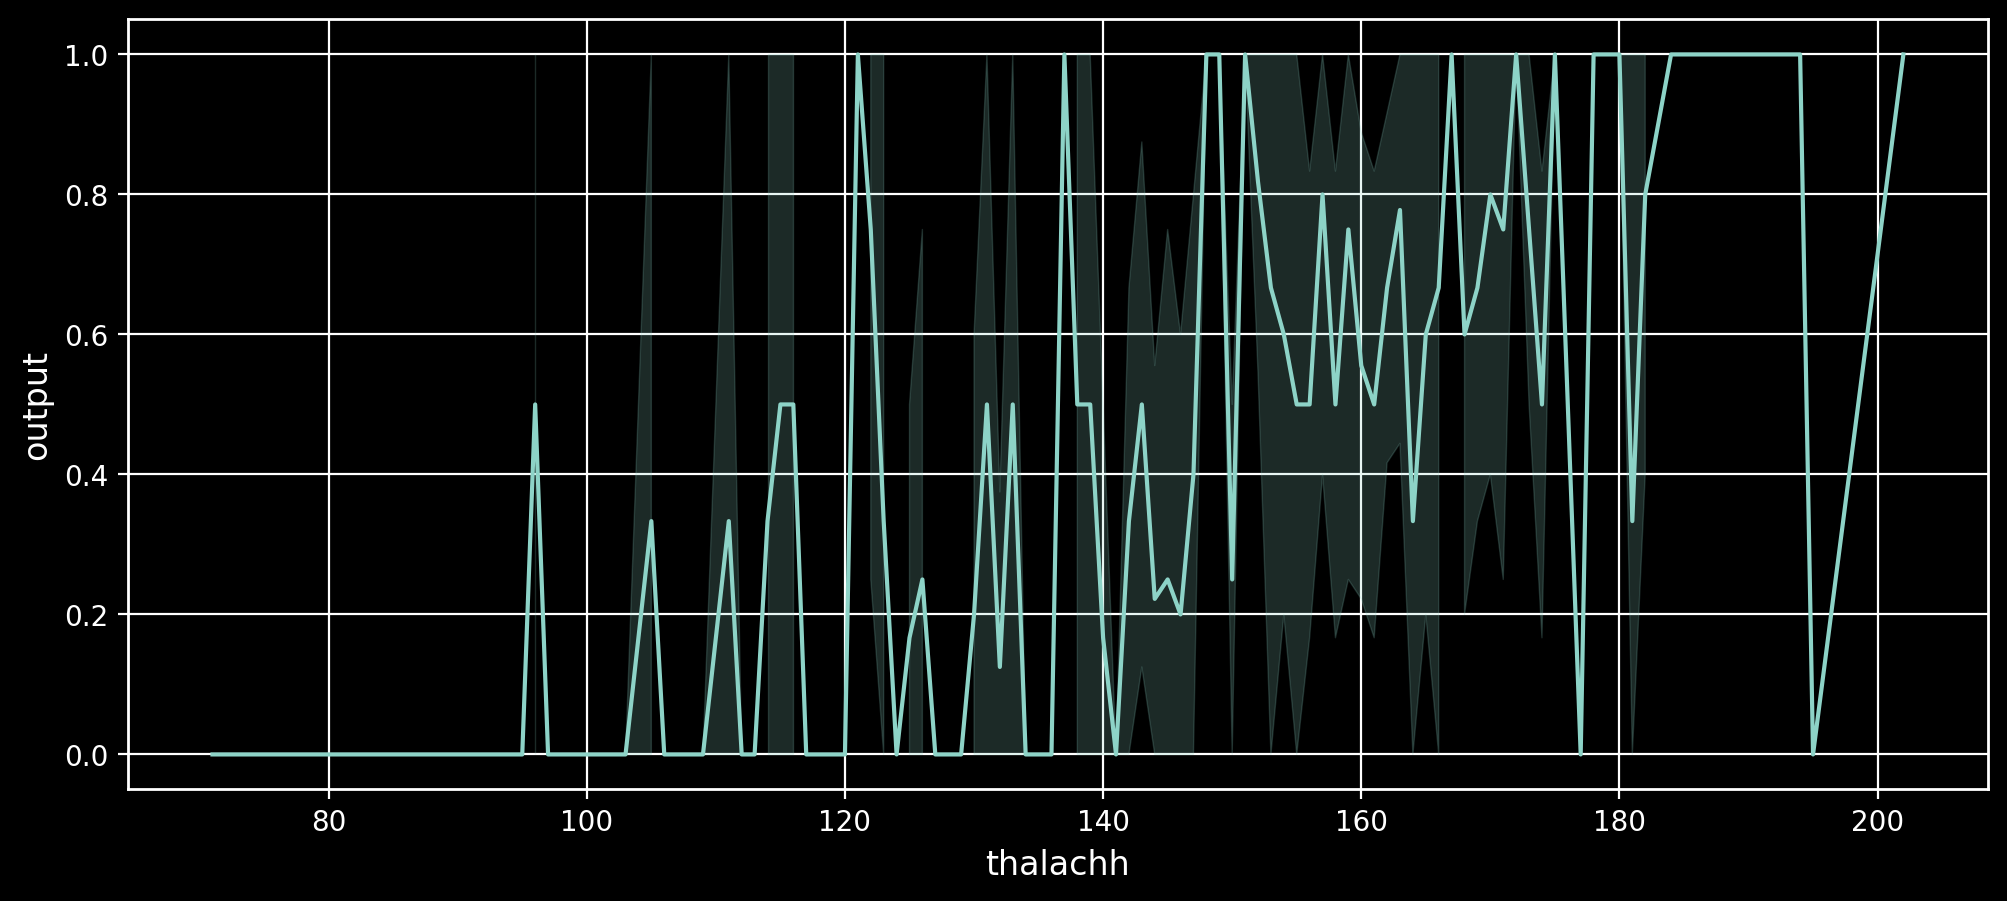

In [93]:
#thalachh
#output
plt.figure(figsize = (12,5), dpi = 200)
sns.lineplot(x = 'thalachh', y = 'output' , data = data)

---

> Add blockquote


---
**11. Determine whether ST/HR (ST segment and Heart rate ratio) is a singificant factor in determining heart attack risk.**

<Axes: xlabel='slp'>

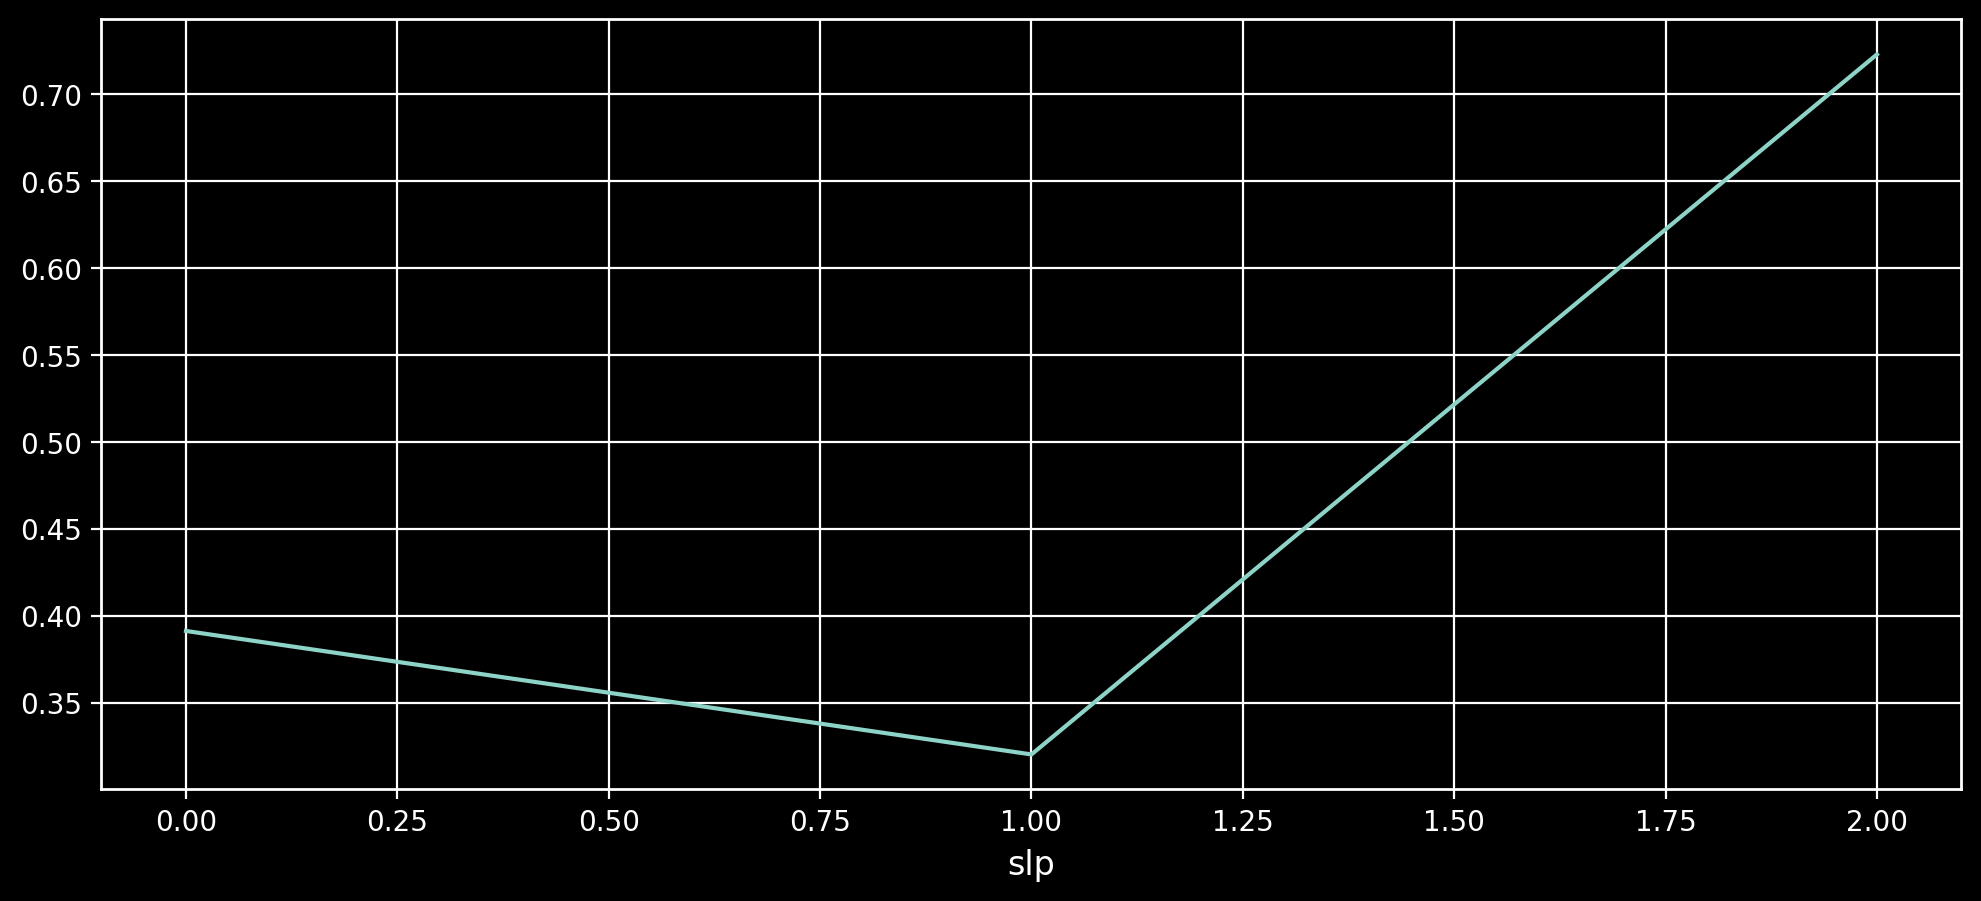

In [100]:
plt.figure(figsize=(12,5), dpi=200)
sns.lineplot(x=data.groupby('slp')['output'].mean().index,
             y=data.groupby('slp')['output'].mean().values)


## End!